In [1]:
import matplotlib.pyplot as plt 
import numpy as np
import pandas as pd
from scipy.stats import norm, beta
import matplotlib.patches as patches
from numpy.random import default_rng
rng = default_rng()
%matplotlib inline

# introduction to Taylor diagrams

Taylor diagrams (Taylor 2001) display aspects of the statistical relationship between two fields, using the Law of Cosines with the decomposition of mean squared error (centered). In this notebook, we introduce the Taylor diagram.

The means of the forecast and observed field must be subtracted out before computing the centered mean squared difference as well as the variances of the forecast and observed fields. The resulting decomposition of the centered mean squared difference provides the following:

$MSE'= s_f^2 + s_x^2 - 2 s_f s_x r_{fx}$

Where $s_f^2$ is the sample variance of the forecast, $s_x^2$ is the sample variance of the observations, and $r_{fx}$ is the correlation coefficient between the forecast and observed fields. A Taylor diagram is constructed using the similarity of the previous equation to the Law of Cosines:

$c^2 = a^2 + b^2 - 2a b cos\phi$

A Taylor diagram is effectively a polar-coordinate space, where the radius from the origin represents the standard deviation of the forecast and the angle is related to the correlation coefficient. A perfect forecast is located along the x-axis at x=1, y=0, representing perfect correlation and sharpness. Correlation coefficient is equal to the cosine of the angle between the forecast performance point and the x-axis on the chart. The x,y space can be normalized by dividing $MSE'$ by the observed variance, resulting in these coordinates:

$\phi = arccos(r_{fx})$

$x = s_f/s_x cos(\phi)$

$y = s_f/s_x sin(\phi)$

$MSE'/s_x^2= s_f^2/s_x^2 + 1 - 2 s_f/s_x r_{fx}$

$=x^2+y^2+1-2x=(x-1)^2+y^2$

Typically, lines of constant correlation are plotted along with contours of constant $MSE'$

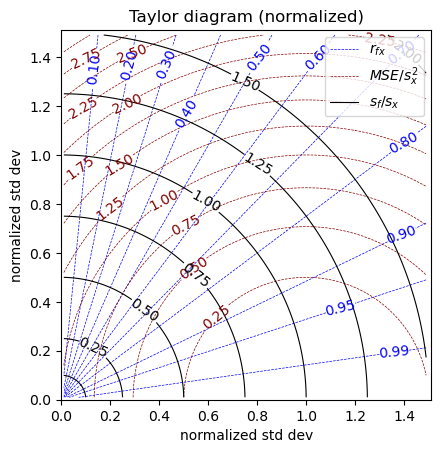

In [2]:
# normalized Taylor diagram
# x = s_f/s_x cos(phi)
# y = s_f/s_x sin(phi)
# phi = arccos(r_fx)

titl1=r'Taylor diagram (normalized)'

x1d_norm=np.arange(0.01,1.5,0.01)
y1d_norm=np.arange(0.01,1.5,0.01)
xx_norm,yy_norm=np.meshgrid(x1d_norm,y1d_norm)

# set up Taylor diagram background contours
sf2_sx2=xx_norm**2+yy_norm**2
rfx_taylor=xx_norm/np.sqrt(sf2_sx2)
mse_norm=(xx_norm-1.0)**2+yy_norm**2
# blue contours: correlation
cs2=plt.contour(xx_norm,yy_norm,rfx_taylor,levels=[0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,0.95,0.99],colors='b',linestyles='dashed',linewidths=0.5)
plt.clabel(cs2, cs2.levels, inline=True, fontsize=10)
# red contours: normalized centered MSE = MSE/s_x^2
cs1=plt.contour(xx_norm,yy_norm,mse_norm,levels=np.linspace(0.25,3.,12),colors='xkcd:dark red',linestyles='dashed',linewidths=0.5)
plt.clabel(cs1, cs1.levels, inline=True, fontsize=10)
# black contours: std dev of fcst / std dev of obs = s_f/s_x
cs3=plt.contour(xx_norm,yy_norm,np.sqrt(sf2_sx2),levels=[0.1,0.25,0.5,0.75,1.,1.25,1.5,2.,3.,4.,10.],colors='k',linewidths=0.8)
plt.clabel(cs3, cs3.levels, inline=True, fontsize=10)

# plot lines for legend/labels
plt.plot([-1,-2],[-1,-2],label=r'$r_{fx}$',c='b',ls='dashed',lw=0.5)
plt.plot([-1,-2],[-1,-2],label=r'$MSE/s_x^2$',c='xkcd:dark red',ls='dashed',lw=0.5)
plt.plot([-1,-2],[-1,-2],label=r'$s_f/s_x$',c='k',lw=0.8)
plt.legend()

plt.title(titl1)
plt.xlabel('normalized std dev')
plt.ylabel('normalized std dev')
plt.xlim(0.,1.51)
plt.ylim(0.,1.51)
plt.gca().set_aspect('equal')

## generate synthetic forecast/observed data

The python function synth_data will generate sythetic continuous forecasts and observations that have some degree of correlation (rhoxf) between them and also allow the user to control the forecast bias and sharpness (distribution of the forecast values). A bivariate normal distribution is generated with specified correlation, the resulting variables are used to generate the forecast and observed values.

In [3]:
def synth_data(nn,xbar,sx2,fbar,sharp,rhoxf):
    # generate synthetic obs with mean = xbar and variance = sx2
    # generate synthetic forecasts with mean = fbar and variance = sharp*sx2
    # rhoxf controls the correlation of the bivariate normal that is used to generate obs and fcst
    # sharp controls the normalized sharpness 
    sf2=sharp*sx2
    sfx=rhoxf*np.sqrt(sf2)*np.sqrt(sx2)
    # set up covariance matrix for bivariate normal distribution
    cov = np.array([[sf2,sfx ], [sfx,sx2]])
    # pull sample of bivariate normal
    pts = rng.multivariate_normal([fbar, xbar], cov, size=nn)
    fcst=pts[:,0]
    obs=pts[:,1]
    return obs,fcst

In [4]:
# example data
# two synthetic forecasts are generated, by adding random noise to the first forecast

obs,fcst1 = synth_data(10000,1.,10.,1.,0.75,0.75)

# seed for random number generator
fcst_rng = np.random.default_rng(42)
fcst2=fcst1+(rng.random(10000)-0.5)*10.

# calculate stats for Taylor diagram
sx2_ex=np.var(obs)
sf2_ex1=np.var(fcst1)
sf2_ex2=np.var(fcst2)
sf_sx_ex1=np.sqrt(sf2_ex1/sx2_ex)
sf_sx_ex2=np.sqrt(sf2_ex2/sx2_ex)
xbar_ex=np.mean(obs)
fbar_ex1=np.mean(fcst1)
fbar_ex2=np.mean(fcst2)
r_fx_ex1=np.corrcoef([obs,fcst1])[0][1]
r_fx_ex2=np.corrcoef([obs,fcst2])[0][1]
mse_ex1=np.mean(np.square((fcst1-fbar_ex1)-(obs-xbar_ex)))
mse_ex2=np.mean(np.square((fcst2-fbar_ex2)-(obs-xbar_ex)))

print('s_x^2 = ',sx2_ex)
print('s_f^2 #1 = ',sf2_ex1)
print('s_f^2 #2 = ',sf2_ex2)
print('s_f/s_x #1 = ',sf_sx_ex1)
print('s_f/s_x #2 = ',sf_sx_ex2)
print('r_fx #1 = ',r_fx_ex1)
print('r_fx #2 = ',r_fx_ex2)
print('centered MSE #1 = ',mse_ex1)
print('centered MSE #2 = ',mse_ex2)
print('centered MSE/s_x^2 #1 = ',mse_ex1/sx2_ex)
print('centered MSE/s_x^2 #2 = ',mse_ex2/sx2_ex)

s_x^2 =  9.915667268813698
s_f^2 #1 =  7.4800462318702525
s_f^2 #2 =  15.992887056536702
s_f/s_x #1 =  0.868542688115467
s_f/s_x #2 =  1.26999632008965
r_fx #1 =  0.7547071630415579
r_fx #2 =  0.5253020547503907
centered MSE #1 =  4.396365170843436
centered MSE #2 =  12.678442868654813
centered MSE/s_x^2 #1 =  0.44337562482261605
centered MSE/s_x^2 #2 =  1.2786273001041968


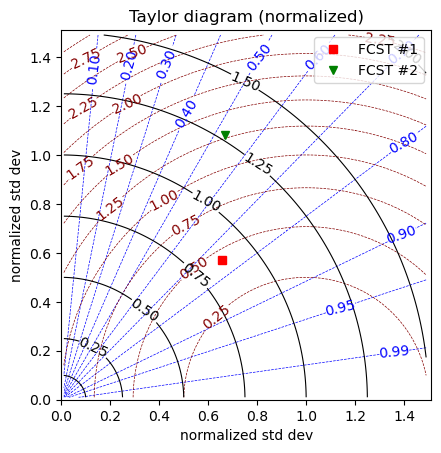

In [5]:
# normalized Taylor diagram
# x = s_f/s_x cos(phi)
# y = s_f/s_x sin(phi)
# phi = arccos(r_fx)

titl1=r'Taylor diagram (normalized)'

x1d_norm=np.arange(0.01,1.5,0.01)
y1d_norm=np.arange(0.01,1.5,0.01)
xx_norm,yy_norm=np.meshgrid(x1d_norm,y1d_norm)

# set up Taylor diagram background contours
sf2_sx2=xx_norm**2+yy_norm**2
rfx_taylor=xx_norm/np.sqrt(sf2_sx2)
mse_norm=(xx_norm-1.0)**2+yy_norm**2
# blue contours: correlation
cs2=plt.contour(xx_norm,yy_norm,rfx_taylor,levels=[0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,0.95,0.99],colors='b',linestyles='dashed',linewidths=0.5)
plt.clabel(cs2, cs2.levels, inline=True, fontsize=10)
# red contours: normalized centered MSE = MSE/s_x^2
cs1=plt.contour(xx_norm,yy_norm,mse_norm,levels=np.linspace(0.25,3.,12),colors='xkcd:dark red',linestyles='dashed',linewidths=0.5)
plt.clabel(cs1, cs1.levels, inline=True, fontsize=10)
# black contours: std dev of fcst / std dev of obs = s_f/s_x
cs3=plt.contour(xx_norm,yy_norm,np.sqrt(sf2_sx2),levels=[0.1,0.25,0.5,0.75,1.,1.25,1.5,2.,3.,4.,10.],colors='k',linewidths=0.8)
plt.clabel(cs3, cs3.levels, inline=True, fontsize=10)

# plot scores at discrete points in Taylor space
plt.plot(sf_sx_ex1*r_fx_ex1,sf_sx_ex1*np.sin(np.arccos(r_fx_ex1)),c='r',ls='none',marker='s',label='FCST #1')
plt.plot(sf_sx_ex2*r_fx_ex2,sf_sx_ex2*np.sin(np.arccos(r_fx_ex2)),c='g',ls='none',marker='v',label='FCST #2')
plt.legend()

plt.title(titl1)
plt.xlabel('normalized std dev')
plt.ylabel('normalized std dev')
plt.xlim(0.,1.51)
plt.ylim(0.,1.51)
plt.gca().set_aspect('equal')



# correlation/sharpness diagrams

A similar diagram can be constructed using the two-dimensional space of correlation coefficient (y-axis) and normalized sharpness (x-axis). As before, the decomposition of mean squared error (centered) is used. We can display the same contours of $r_{fx}$, $s_f/s_x$, and $MSE'/s_x^2$ in the background of this diagram. 

$MSE'= s_f^2 + s_x^2 - 2 s_f s_x r_{fx}$

Normalizing $MSE'$ by the observed variance, results in these coordinates:

$x = s_f/s_x$

$y = r_{fx}$

$MSE'/s_x^2= s_f^2/s_x^2 + 1 - 2 s_f/s_x r_{fx}=x^2+1-2xy$

The dashed black line indicates the optimal sharpness for minimizing $MSE'$ for a given level of correlation ($r_{fx}=s_f/s_x$).


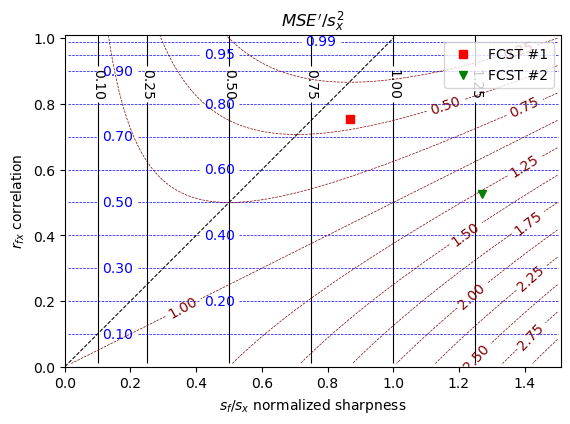

In [6]:
# plot scores at discrete points in 2-D space of normalized sharpness and correlation

titl1=r"$MSE'/s_x^2$"

# interpolate score at discrete points to a regular grid for contouring in normalized sharpness/correlation space
x1d=np.arange(0.01,1.51,.01)
y1d=np.arange(0.01,1.02,.01)
xx,yy=np.meshgrid(x1d,y1d)

# black contours: std dev of fcst / std dev of obs = sf/sx
cs3=plt.contour(xx,yy,xx,levels=[0.1,0.25,0.5,0.75,1.,1.25,1.5,2.,3.,4.,10.],colors='k',linewidths=0.8)
plt.clabel(cs3, cs3.levels, inline=True, fontsize=10)
# blue contours: correlation
cs2=plt.contour(xx,yy,yy,levels=[0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,0.95,0.99],colors='b',linestyles='dashed',linewidths=0.5)
plt.clabel(cs2, cs2.levels, inline=True, fontsize=10)
# red contours: normalized MSE = MSE/uncertainty
cs1=plt.contour(xx,yy,xx*xx-2.*xx*yy+1.,levels=np.linspace(0.25,3.,12),colors='xkcd:dark red',linestyles='dashed',linewidths=0.5)
plt.clabel(cs1, cs1.levels, inline=True, fontsize=10)
# optimal sharpness line
plt.plot([0,1],[0,1],'k--',lw=0.75)


# plot scores as discrete points as color scatter points
plt.plot(sf_sx_ex1,r_fx_ex1,c='r',ls='none',marker='s',label='FCST #1')
plt.plot(sf_sx_ex2,r_fx_ex2,c='g',ls='none',marker='v',label='FCST #2')
plt.legend()



plt.title(titl1)
plt.xlabel(r'$s_f/s_x$ normalized sharpness')
plt.ylabel(r'$r_{fx}$ correlation')
plt.xlim(0.,1.51)
plt.ylim(0.,1.01)
plt.gca().set_aspect('equal')

